In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd
from PIL import Image

import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Configuración de estilo para gráficos
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Semilla para reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow version: {tf.__version__}')
print(f'NumPy version: {np.__version__}')
print(f'GPU disponible: {tf.config.list_physical_devices("GPU")}')

TensorFlow version: 2.19.0
NumPy version: 2.0.2
GPU disponible: []


## 2. Cargar Modelo y Datos de Test

In [13]:
# ============================================================
# ⚠️ AJUSTA ESTAS RUTAS SEGÚN TU ENTORNO
# ============================================================

# --- Opción A: Ejecución LOCAL ---
MODEL_PATH = '../models/modelo_cervical.h5'
TEST_DIR = '../data/procesado/test'

# --- Opción B: Google Colab (descomenta si usas Colab) ---
# from google.colab import drive
# drive.mount('/content/drive')
# MODEL_PATH = '/content/drive/MyDrive/ia-cancer/modelo_cervical.h5'
# TEST_DIR = '/content/drive/MyDrive/ia-cancer/data/procesado/test'

# Verificar que existen
print(f'Modelo existe: {os.path.exists(MODEL_PATH)}')
print(f'Directorio test existe: {os.path.exists(TEST_DIR)}')

if os.path.exists(TEST_DIR):
    for clase in os.listdir(TEST_DIR):
        clase_path = os.path.join(TEST_DIR, clase)
        if os.path.isdir(clase_path):
            n = len(os.listdir(clase_path))
            print(f'  {clase}: {n} imágenes')

Modelo existe: False
Directorio test existe: False


In [1]:
from google.colab import files
uploaded = files.upload()  # Selecciona modelo_cervical.h5
MODEL_PATH = 'modelo_cervical.h5'

Saving modelo_cervical.h5 to modelo_cervical.h5


In [7]:
from google.colab import drive
drive.mount('/content/drive')

# Descomprimir test
!unzip "/content/drive/MyDrive/test.zip" -d "/content/test_data"

# Verificar
!ls /content/test_data/

Mounted at /content/drive
Archive:  /content/drive/MyDrive/test.zip
   creating: /content/test_data/test/
   creating: /content/test_data/test/anormal/
  inflating: /content/test_data/test/anormal/anormal_0000.jpg  
  inflating: /content/test_data/test/anormal/anormal_0001.jpg  
  inflating: /content/test_data/test/anormal/anormal_0002.jpg  
  inflating: /content/test_data/test/anormal/anormal_0003.jpg  
  inflating: /content/test_data/test/anormal/anormal_0004.jpg  
  inflating: /content/test_data/test/anormal/anormal_0005.jpg  
  inflating: /content/test_data/test/anormal/anormal_0006.jpg  
  inflating: /content/test_data/test/anormal/anormal_0007.jpg  
  inflating: /content/test_data/test/anormal/anormal_0008.jpg  
  inflating: /content/test_data/test/anormal/anormal_0009.jpg  
  inflating: /content/test_data/test/anormal/anormal_0010.jpg  
  inflating: /content/test_data/test/anormal/anormal_0011.jpg  
  inflating: /content/test_data/test/anormal/anormal_0012.jpg  
  inflating: /co

In [9]:
!unzip -o "/content/drive/MyDrive/test.zip" -d "/content/test_data"
TEST_DIR = '/content/test_data/test'

# Verificar
!echo "Estructura:"
!ls /content/test_data/test/
!echo "Normal:" && ls /content/test_data/test/normal/ | wc -l
!echo "Anormal:" && ls /content/test_data/test/anormal/ | wc -l

Archive:  /content/drive/MyDrive/test.zip
  inflating: /content/test_data/test/anormal/anormal_0000.jpg  
  inflating: /content/test_data/test/anormal/anormal_0001.jpg  
  inflating: /content/test_data/test/anormal/anormal_0002.jpg  
  inflating: /content/test_data/test/anormal/anormal_0003.jpg  
  inflating: /content/test_data/test/anormal/anormal_0004.jpg  
  inflating: /content/test_data/test/anormal/anormal_0005.jpg  
  inflating: /content/test_data/test/anormal/anormal_0006.jpg  
  inflating: /content/test_data/test/anormal/anormal_0007.jpg  
  inflating: /content/test_data/test/anormal/anormal_0008.jpg  
  inflating: /content/test_data/test/anormal/anormal_0009.jpg  
  inflating: /content/test_data/test/anormal/anormal_0010.jpg  
  inflating: /content/test_data/test/anormal/anormal_0011.jpg  
  inflating: /content/test_data/test/anormal/anormal_0012.jpg  
  inflating: /content/test_data/test/anormal/anormal_0013.jpg  
  inflating: /content/test_data/test/anormal/anormal_0014.jpg 

In [10]:
!find /content/drive/MyDrive -name "modelo_cervical.h5" 2>/dev/null

/content/drive/MyDrive/modelo_cervical.h5


In [14]:
MODEL_PATH = '/content/drive/MyDrive/modelo_cervical.h5'
TEST_DIR = '/content/test_data/test'

model = load_model(MODEL_PATH)
print('✅ Modelo cargado exitosamente')
print(f'Input shape: {model.input_shape}')
print(f'Output shape: {model.output_shape}')

✅ Modelo cargado exitosamente
Input shape: (None, 224, 224, 3)
Output shape: (None, 1)


In [15]:
# Preparar generador de test
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print(f'\nMapeo de clases: {test_generator.class_indices}')
print(f'Total imágenes: {test_generator.samples}')

Found 291 images belonging to 2 classes.

Mapeo de clases: {'anormal': 0, 'normal': 1}
Total imágenes: 291


In [16]:
# Obtener predicciones
test_generator.reset()
y_prob = model.predict(test_generator, verbose=1)
y_prob = y_prob.flatten()

y_true = test_generator.classes
y_pred = (y_prob >= 0.5).astype(int)
filenames = test_generator.filenames

print(f'Predicciones: {y_prob.shape}')
print(f'Min: {y_prob.min():.4f}, Max: {y_prob.max():.4f}, Media: {y_prob.mean():.4f}')

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


19/19 ━━━━━━━━━━━━━━━━━━━━ 51s 3s/step
Predicciones: (291,)
Min: 0.0003, Max: 0.9925, Media: 0.5218


In [17]:
# Invertir para que ANORMAL = 1 (positivo médico)
# Porque anormal=0 en el generador, necesitamos invertir
y_true_med = 1 - y_true
y_pred_med = 1 - y_pred
y_prob_med = 1 - y_prob
POSITIVE_LABEL = 'ANORMAL'
NEGATIVE_LABEL = 'NORMAL'

print(f'Positivos (anormal) en test: {y_true_med.sum()}')
print(f'Negativos (normal) en test: {(1 - y_true_med).sum()}')


Positivos (anormal) en test: 139
Negativos (normal) en test: 152


In [18]:
# === MÉTRICAS ===
cm = confusion_matrix(y_true_med, y_pred_med)
tn, fp, fn, tp = cm.ravel()

accuracy = accuracy_score(y_true_med, y_pred_med)
precision = precision_score(y_true_med, y_pred_med)
recall = recall_score(y_true_med, y_pred_med)
f1 = f1_score(y_true_med, y_pred_med)
specificity = tn / (tn + fp)

print('=' * 60)
print('  MÉTRICAS - MODELO CÁNCER CERVICAL')
print('=' * 60)
print(f'''
  Accuracy:          {accuracy:.4f}  ({accuracy*100:.2f}%)
  Sensibilidad:      {recall:.4f}  ({recall*100:.2f}%)
  Especificidad:     {specificity:.4f}  ({specificity*100:.2f}%)
  Precision (VPP):   {precision:.4f}  ({precision*100:.2f}%)
  F1-Score:          {f1:.4f}  ({f1*100:.2f}%)

  TP: {tp}  |  TN: {tn}  |  FP: {fp}  |  FN: {fn}
''')
print(classification_report(y_true_med, y_pred_med, target_names=[NEGATIVE_LABEL, POSITIVE_LABEL], digits=4))

  MÉTRICAS - MODELO CÁNCER CERVICAL

  Accuracy:          0.8179  (81.79%)
  Sensibilidad:      0.7770  (77.70%)
  Especificidad:     0.8553  (85.53%)
  Precision (VPP):   0.8308  (83.08%)
  F1-Score:          0.8030  (80.30%)

  TP: 108  |  TN: 130  |  FP: 22  |  FN: 31

              precision    recall  f1-score   support

      NORMAL     0.8075    0.8553    0.8307       152
     ANORMAL     0.8308    0.7770    0.8030       139

    accuracy                         0.8179       291
   macro avg     0.8191    0.8161    0.8168       291
weighted avg     0.8186    0.8179    0.8174       291



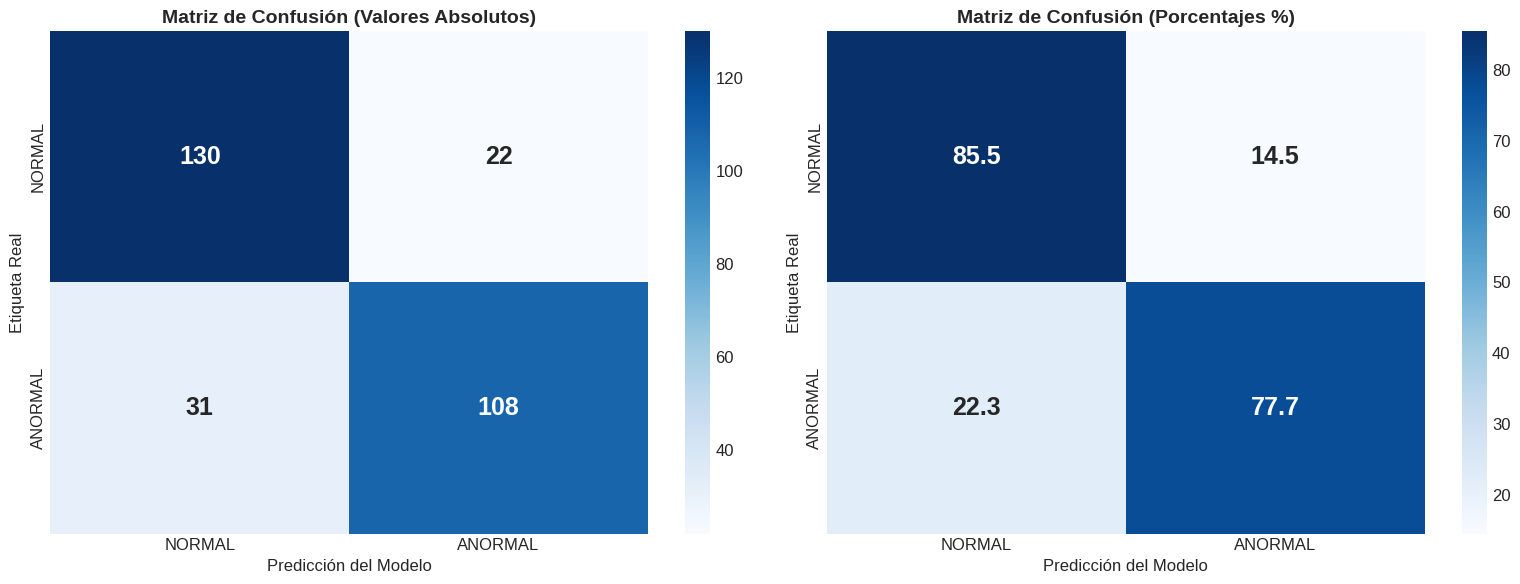

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[NEGATIVE_LABEL, POSITIVE_LABEL],
            yticklabels=[NEGATIVE_LABEL, POSITIVE_LABEL],
            ax=axes[0], annot_kws={'size': 18, 'weight': 'bold'})
axes[0].set_ylabel('Etiqueta Real')
axes[0].set_xlabel('Predicción del Modelo')
axes[0].set_title('Matriz de Confusión (Valores Absolutos)', fontweight='bold')

cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=[NEGATIVE_LABEL, POSITIVE_LABEL],
            yticklabels=[NEGATIVE_LABEL, POSITIVE_LABEL],
            ax=axes[1], annot_kws={'size': 18, 'weight': 'bold'})
axes[1].set_ylabel('Etiqueta Real')
axes[1].set_xlabel('Predicción del Modelo')
axes[1].set_title('Matriz de Confusión (Porcentajes %)', fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

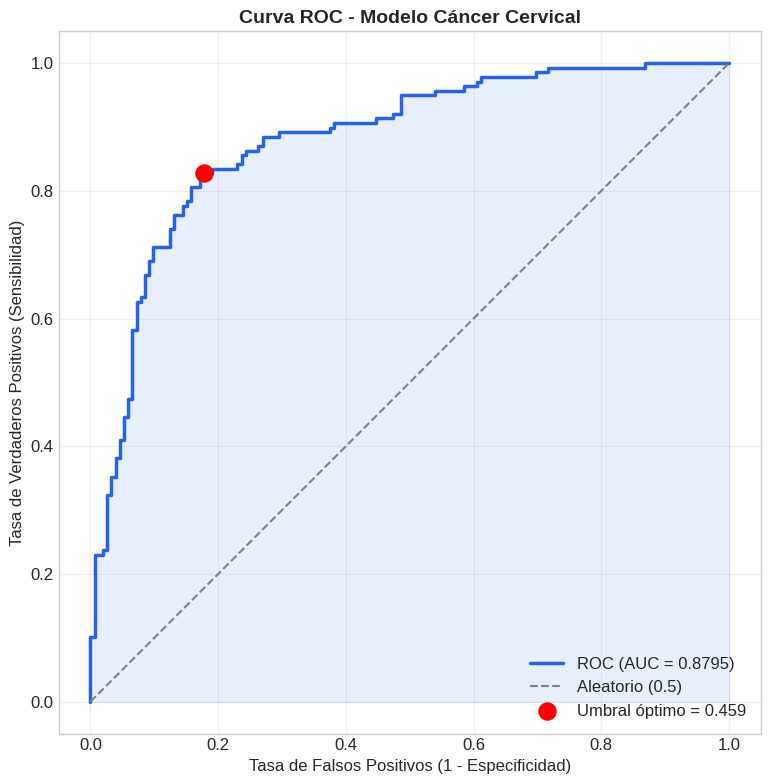

AUC-ROC: 0.8795
Umbral óptimo (Youden): 0.4590


In [20]:
fpr, tpr, thresholds_roc = roc_curve(y_true_med, y_prob_med)
roc_auc = auc(fpr, tpr)

j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold_roc = thresholds_roc[best_idx]

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(fpr, tpr, color='#2563EB', lw=2.5, label=f'ROC (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Aleatorio (0.5)')
ax.scatter(fpr[best_idx], tpr[best_idx], color='red', s=150, zorder=5,
           label=f'Umbral óptimo = {best_threshold_roc:.3f}')
ax.fill_between(fpr, tpr, alpha=0.1, color='#2563EB')
ax.set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
ax.set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
ax.set_title('Curva ROC - Modelo Cáncer Cervical', fontweight='bold')
ax.legend(loc='lower right')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'AUC-ROC: {roc_auc:.4f}')
print(f'Umbral óptimo (Youden): {best_threshold_roc:.4f}')

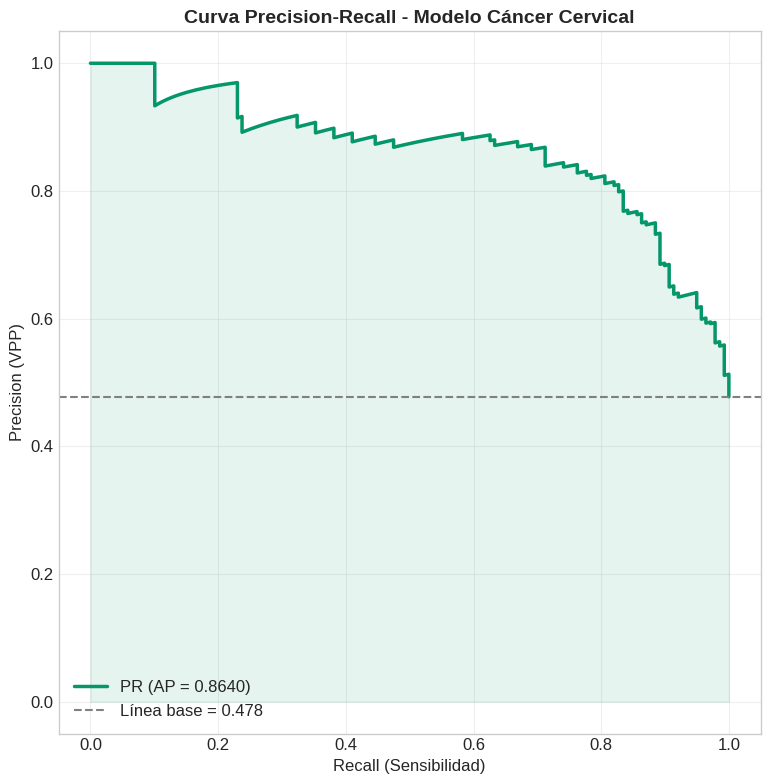

Average Precision: 0.8640


In [21]:
prec_curve, rec_curve, _ = precision_recall_curve(y_true_med, y_prob_med)
avg_precision = average_precision_score(y_true_med, y_prob_med)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(rec_curve, prec_curve, color='#059669', lw=2.5, label=f'PR (AP = {avg_precision:.4f})')
baseline = y_true_med.sum() / len(y_true_med)
ax.axhline(y=baseline, color='gray', linestyle='--', lw=1.5, label=f'Línea base = {baseline:.3f}')
ax.fill_between(rec_curve, prec_curve, alpha=0.1, color='#059669')
ax.set_xlabel('Recall (Sensibilidad)')
ax.set_ylabel('Precision (VPP)')
ax.set_title('Curva Precision-Recall - Modelo Cáncer Cervical', fontweight='bold')
ax.legend(loc='lower left')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('precision_recall_curve.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Average Precision: {avg_precision:.4f}')

/tmp/ipython-input-424108172.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot([y_prob_med[y_true_med == 0], y_prob_med[y_true_med == 1]],


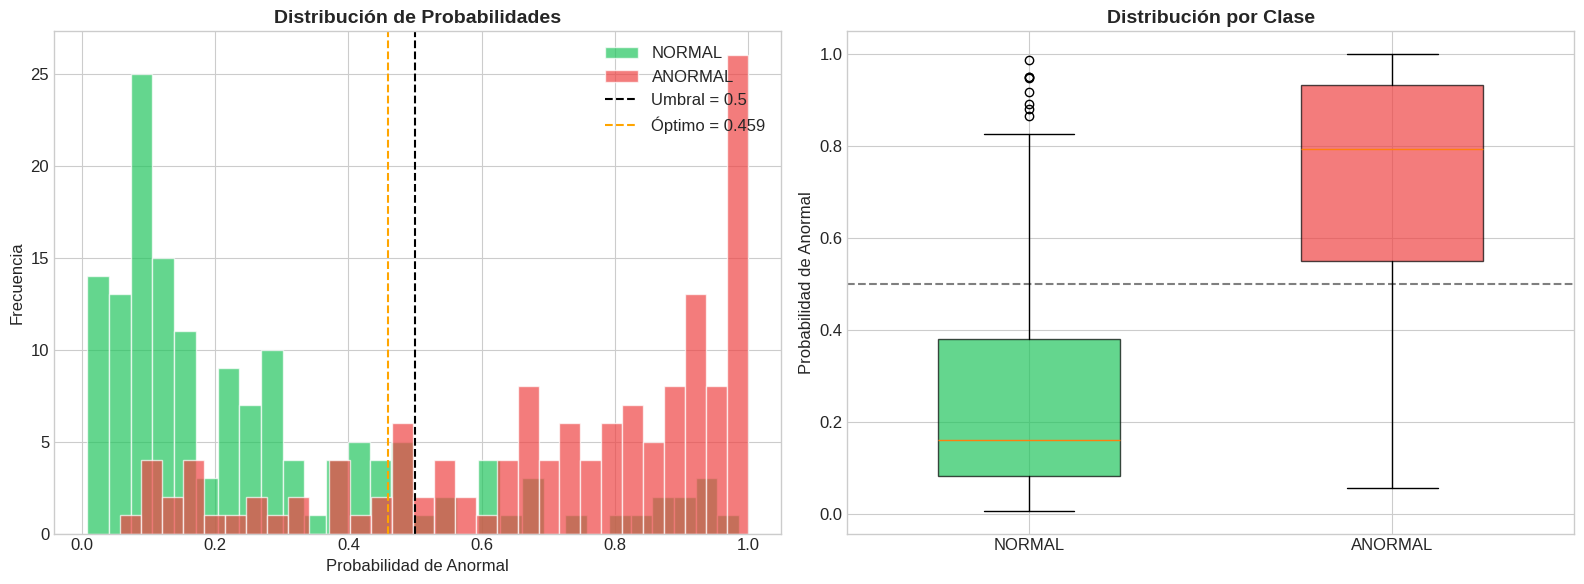

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(y_prob_med[y_true_med == 0], bins=30, alpha=0.7, color='#22C55E', label=NEGATIVE_LABEL, edgecolor='white')
axes[0].hist(y_prob_med[y_true_med == 1], bins=30, alpha=0.7, color='#EF4444', label=POSITIVE_LABEL, edgecolor='white')
axes[0].axvline(x=0.5, color='black', linestyle='--', lw=1.5, label='Umbral = 0.5')
axes[0].axvline(x=best_threshold_roc, color='orange', linestyle='--', lw=1.5, label=f'Óptimo = {best_threshold_roc:.3f}')
axes[0].set_xlabel('Probabilidad de Anormal')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Probabilidades', fontweight='bold')
axes[0].legend()

bp = axes[1].boxplot([y_prob_med[y_true_med == 0], y_prob_med[y_true_med == 1]],
                     labels=[NEGATIVE_LABEL, POSITIVE_LABEL], patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor('#22C55E'); bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('#EF4444'); bp['boxes'][1].set_alpha(0.7)
axes[1].axhline(y=0.5, color='black', linestyle='--', lw=1.5, alpha=0.5)
axes[1].set_ylabel('Probabilidad de Anormal')
axes[1].set_title('Distribución por Clase', fontweight='bold')

plt.tight_layout()
plt.savefig('distribucion_probabilidades.png', dpi=300, bbox_inches='tight')
plt.show()

 Umbral  Accuracy  Sensibilidad  Especificidad  Precision  F1-Score  TP  FP  FN  TN
   0.10    0.6323        0.9784         0.3158     0.5667    0.7177 136 104   3  48
   0.15    0.7010        0.9496         0.4737     0.6226    0.7521 132  80   7  72
   0.20    0.7148        0.9137         0.5329     0.6414    0.7537 127  71  12  81
   0.25    0.7560        0.8993         0.6250     0.6868    0.7788 125  57  14  95
   0.30    0.7938        0.8921         0.7039     0.7337    0.8052 124  45  15 107
   0.35    0.7973        0.8705         0.7303     0.7469    0.8040 121  41  18 111
   0.40    0.8007        0.8417         0.7632     0.7647    0.8014 117  36  22 116
   0.45    0.8179        0.8273         0.8092     0.7986    0.8127 115  29  24 123
   0.50    0.8179        0.7770         0.8553     0.8308    0.8030 108  22  31 130
   0.55    0.8076        0.7410         0.8684     0.8374    0.7863 103  20  36 132
   0.60    0.7973        0.7122         0.8750     0.8390    0.7704  99  19 

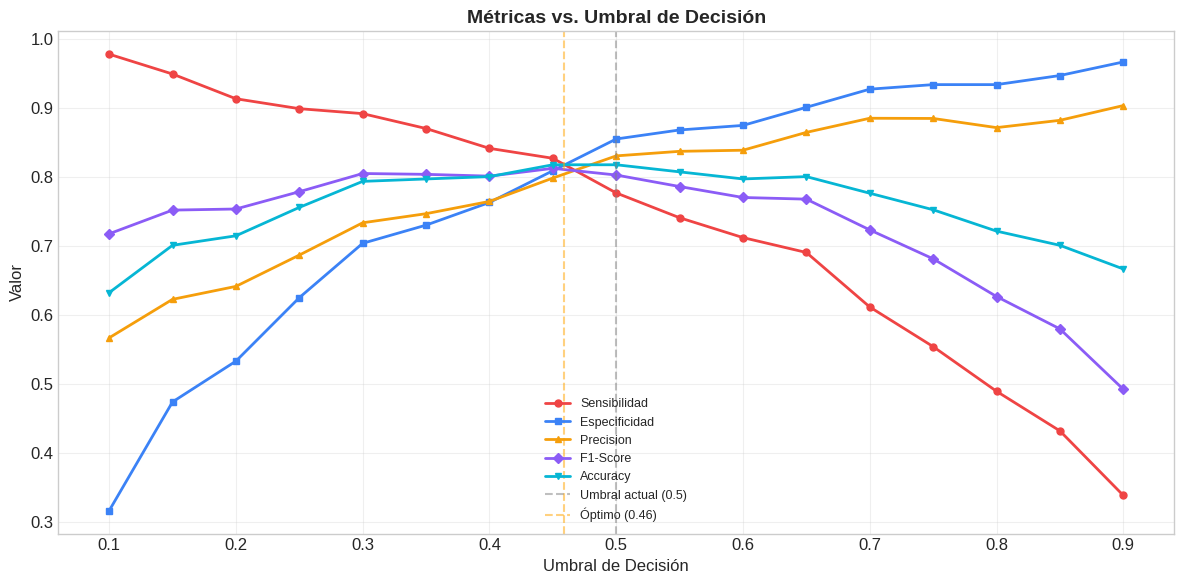

In [23]:
thresholds_analysis = np.arange(0.1, 0.95, 0.05)
results = []
for t in thresholds_analysis:
    y_pred_t = (y_prob_med >= t).astype(int)
    cm_t = confusion_matrix(y_true_med, y_pred_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    results.append({
        'Umbral': round(t, 2), 'Accuracy': round(accuracy_score(y_true_med, y_pred_t), 4),
        'Sensibilidad': round(tp_t/(tp_t+fn_t), 4), 'Especificidad': round(tn_t/(tn_t+fp_t), 4),
        'Precision': round(tp_t/(tp_t+fp_t) if (tp_t+fp_t)>0 else 0, 4),
        'F1-Score': round(f1_score(y_true_med, y_pred_t, zero_division=0), 4),
        'TP': tp_t, 'FP': fp_t, 'FN': fn_t, 'TN': tn_t
    })
df_thresholds = pd.DataFrame(results)
print(df_thresholds.to_string(index=False))

# Gráfico
fig, ax = plt.subplots(figsize=(12, 6))
for col, color, marker in [('Sensibilidad','#EF4444','o'), ('Especificidad','#3B82F6','s'),
                             ('Precision','#F59E0B','^'), ('F1-Score','#8B5CF6','D'), ('Accuracy','#06B6D4','v')]:
    ax.plot(df_thresholds['Umbral'], df_thresholds[col], f'{marker}-', color=color, lw=2, label=col, markersize=5)
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Umbral actual (0.5)')
ax.axvline(x=best_threshold_roc, color='orange', linestyle='--', alpha=0.5, label=f'Óptimo ({best_threshold_roc:.2f})')
ax.set_xlabel('Umbral de Decisión'); ax.set_ylabel('Valor')
ax.set_title('Métricas vs. Umbral de Decisión', fontweight='bold')
ax.legend(loc='best', fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('metricas_vs_umbral.png', dpi=300, bbox_inches='tight')
plt.show()

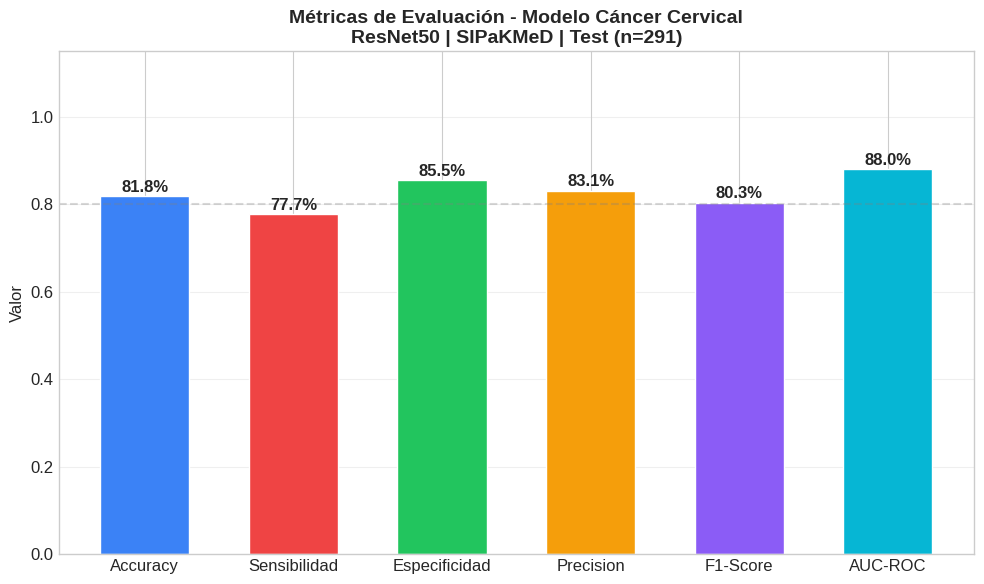

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))
names = ['Accuracy', 'Sensibilidad', 'Especificidad', 'Precision', 'F1-Score', 'AUC-ROC']
values = [accuracy, recall, specificity, precision, f1, roc_auc]
colors_m = ['#3B82F6', '#EF4444', '#22C55E', '#F59E0B', '#8B5CF6', '#06B6D4']
bars = ax.bar(names, values, color=colors_m, edgecolor='white', width=0.6)
for bar, val in zip(bars, values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{val*100:.1f}%', ha='center', fontsize=12, fontweight='bold')
ax.set_ylim([0, 1.15]); ax.set_ylabel('Valor')
ax.set_title('Métricas de Evaluación - Modelo Cáncer Cervical\nResNet50 | SIPaKMeD | Test (n=291)', fontweight='bold')
ax.axhline(y=0.8, color='gray', linestyle='--', alpha=0.3)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('resumen_metricas.png', dpi=300, bbox_inches='tight')
plt.show()